# 05b — Xj Maps ("Urgent Area" Views)

Reads the already-computed Round 2 results (`p_median_results.csv`, P_VALUES=[2000,5000,8000])
directly -- no re-solving needed.

**Colour scheme: OrRd** (white/pale = 0, deep red = high xⱼ) -- reverted from an earlier
blue-white-red attempt, since xⱼ is never negative and the blue half of a diverging colormap
would sit entirely unused. Shared `vmin=0, vmax=<max across the panels being compared>` keeps
colours directly comparable panel-to-panel.

**Every comparison below shows all four scenarios (A/B/C/D) together, not an A-vs-D pair** --
picking two scenarios to contrast implies they're the interesting ones; showing all four lets
you judge that yourself.

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

BASE_CANDIDATES = [
    "/Users/alexia/Documents/CASA/Dissertation",
    os.path.abspath(os.path.join(os.getcwd(), "..")),
]
BASE = next(
    (b for b in BASE_CANDIDATES
     if os.path.exists(os.path.join(b, "05_processed/p_median_results.csv"))),
    BASE_CANDIDATES[0],
)
print("Using BASE:", BASE)

results_wide = pd.read_csv(os.path.join(BASE, "05_processed/p_median_results.csv"))
results_wide["lsoa_code"] = results_wide["lsoa_code"].astype(str)

lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None:
    lsoa_boundaries = lsoa_boundaries.set_crs(epsg=27700)
elif lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)
lsoa_london = lsoa_boundaries.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]
lsoa_london["lsoa_code"] = lsoa_london["lsoa_code"].astype(str)
lsoa_london = lsoa_london[lsoa_london["lsoa_code"].isin(results_wide["lsoa_code"])]

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

XJ_CMAP = "OrRd"

print("Loaded:", results_wide.shape, "| columns available:", [c for c in results_wide.columns if c.startswith("xj_")])


Using BASE: /Users/alexia/Documents/CASA/Dissertation
Loaded: (4994, 26) | columns available: ['xj_A_p2000', 'xj_A_p5000', 'xj_A_p8000', 'xj_B_p2000', 'xj_B_p5000', 'xj_B_p8000', 'xj_C_p2000', 'xj_C_p5000', 'xj_C_p8000', 'xj_D_p2000', 'xj_D_p5000', 'xj_D_p8000']


## Main map — Scenario C, p=5000 (blue-white-red)

p=5000, Scenario C: 4,100 LSOAs need 0 new units, 894 LSOAs are allocated >0 (the 'urgent areas'), max xj = 9


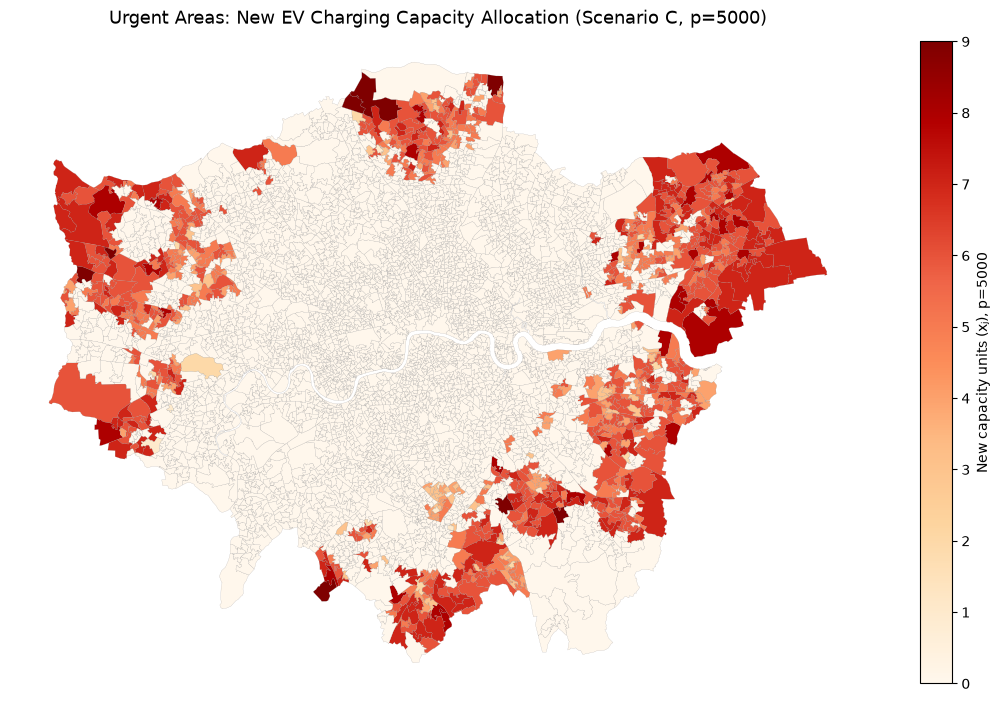

In [7]:
PRIMARY_P = 5000
PRIMARY_SCENARIO = "C"
xj_col = f"xj_{PRIMARY_SCENARIO}_p{PRIMARY_P}"

map_data = lsoa_london.merge(results_wide[["lsoa_code", xj_col]], on="lsoa_code", how="left")
vmax = results_wide[xj_col].max()

n_zero = (results_wide[xj_col] == 0).sum()
n_positive = (results_wide[xj_col] > 0).sum()
print(f"p={PRIMARY_P}, Scenario {PRIMARY_SCENARIO}: {n_zero:,} LSOAs need 0 new units, "
      f"{n_positive:,} LSOAs are allocated >0 (the 'urgent areas'), max xj = {vmax}")

fig, ax = plt.subplots(figsize=(11, 11))
map_data.plot(column=xj_col, cmap=XJ_CMAP, vmin=0, vmax=vmax, linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": f"New capacity units (xⱼ), p={PRIMARY_P}", "shrink": 0.6})
ax.set_title(f"Urgent Areas: New EV Charging Capacity Allocation (Scenario {PRIMARY_SCENARIO}, p={PRIMARY_P})", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"fig_xj_urgent_areas_{PRIMARY_SCENARIO}_p{PRIMARY_P}.png"), dpi=300, bbox_inches="tight")
plt.show()


## Same map across all three tested p values (Scenario C)

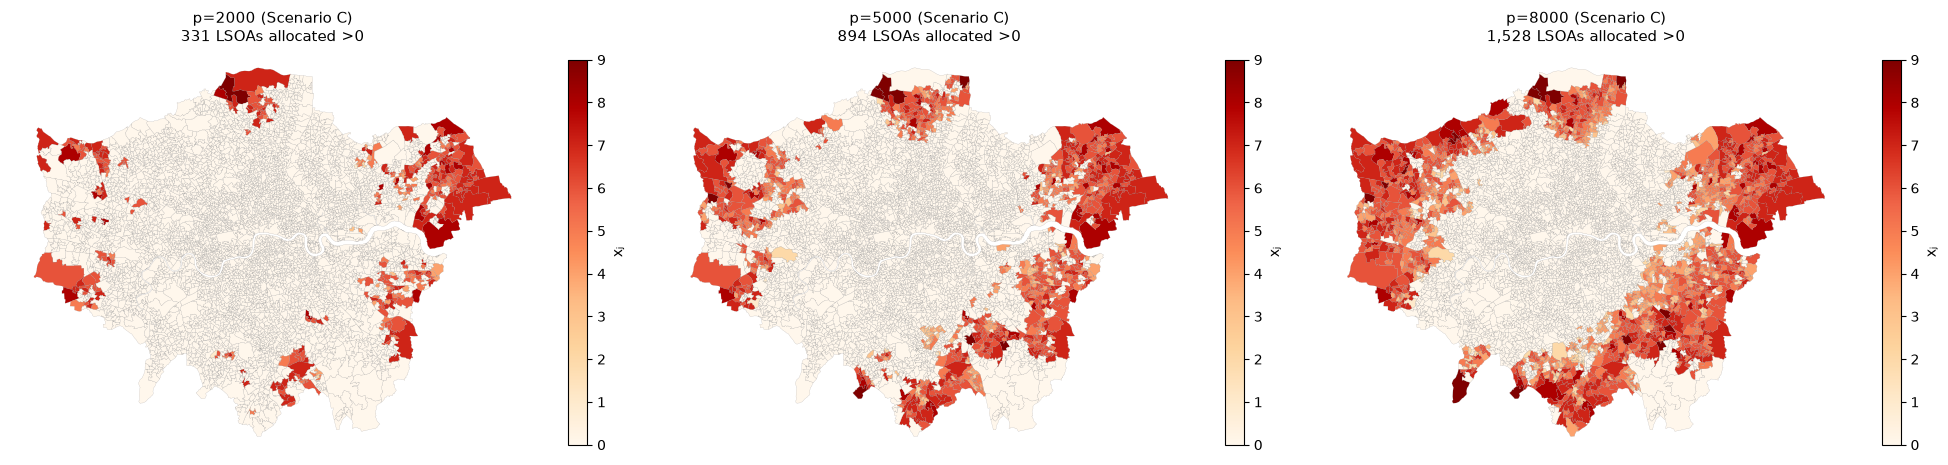

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, p in zip(axes, [2000, 5000, 8000]):
    col = f"xj_{PRIMARY_SCENARIO}_p{p}"
    md_p = lsoa_london.merge(results_wide[["lsoa_code", col]], on="lsoa_code", how="left")
    vmax_p = results_wide[col].max()
    md_p.plot(column=col, cmap=XJ_CMAP, vmin=0, vmax=vmax_p, linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": "xⱼ", "shrink": 0.5})
    n_pos = (results_wide[col] > 0).sum()
    ax.set_title(f"p={p} (Scenario {PRIMARY_SCENARIO})\n{n_pos:,} LSOAs allocated >0", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"fig_xj_urgent_areas_{PRIMARY_SCENARIO}_all_p.png"), dpi=300, bbox_inches="tight")
plt.show()


## All four scenarios together (A/B/C/D), p=5000

Same colour scale (`vmin=-vmax, vmax=vmax`) shared across all four panels, using the single
largest xⱼ value across all four scenarios -- so the colours are directly comparable
panel-to-panel, not each rescaled to its own range.

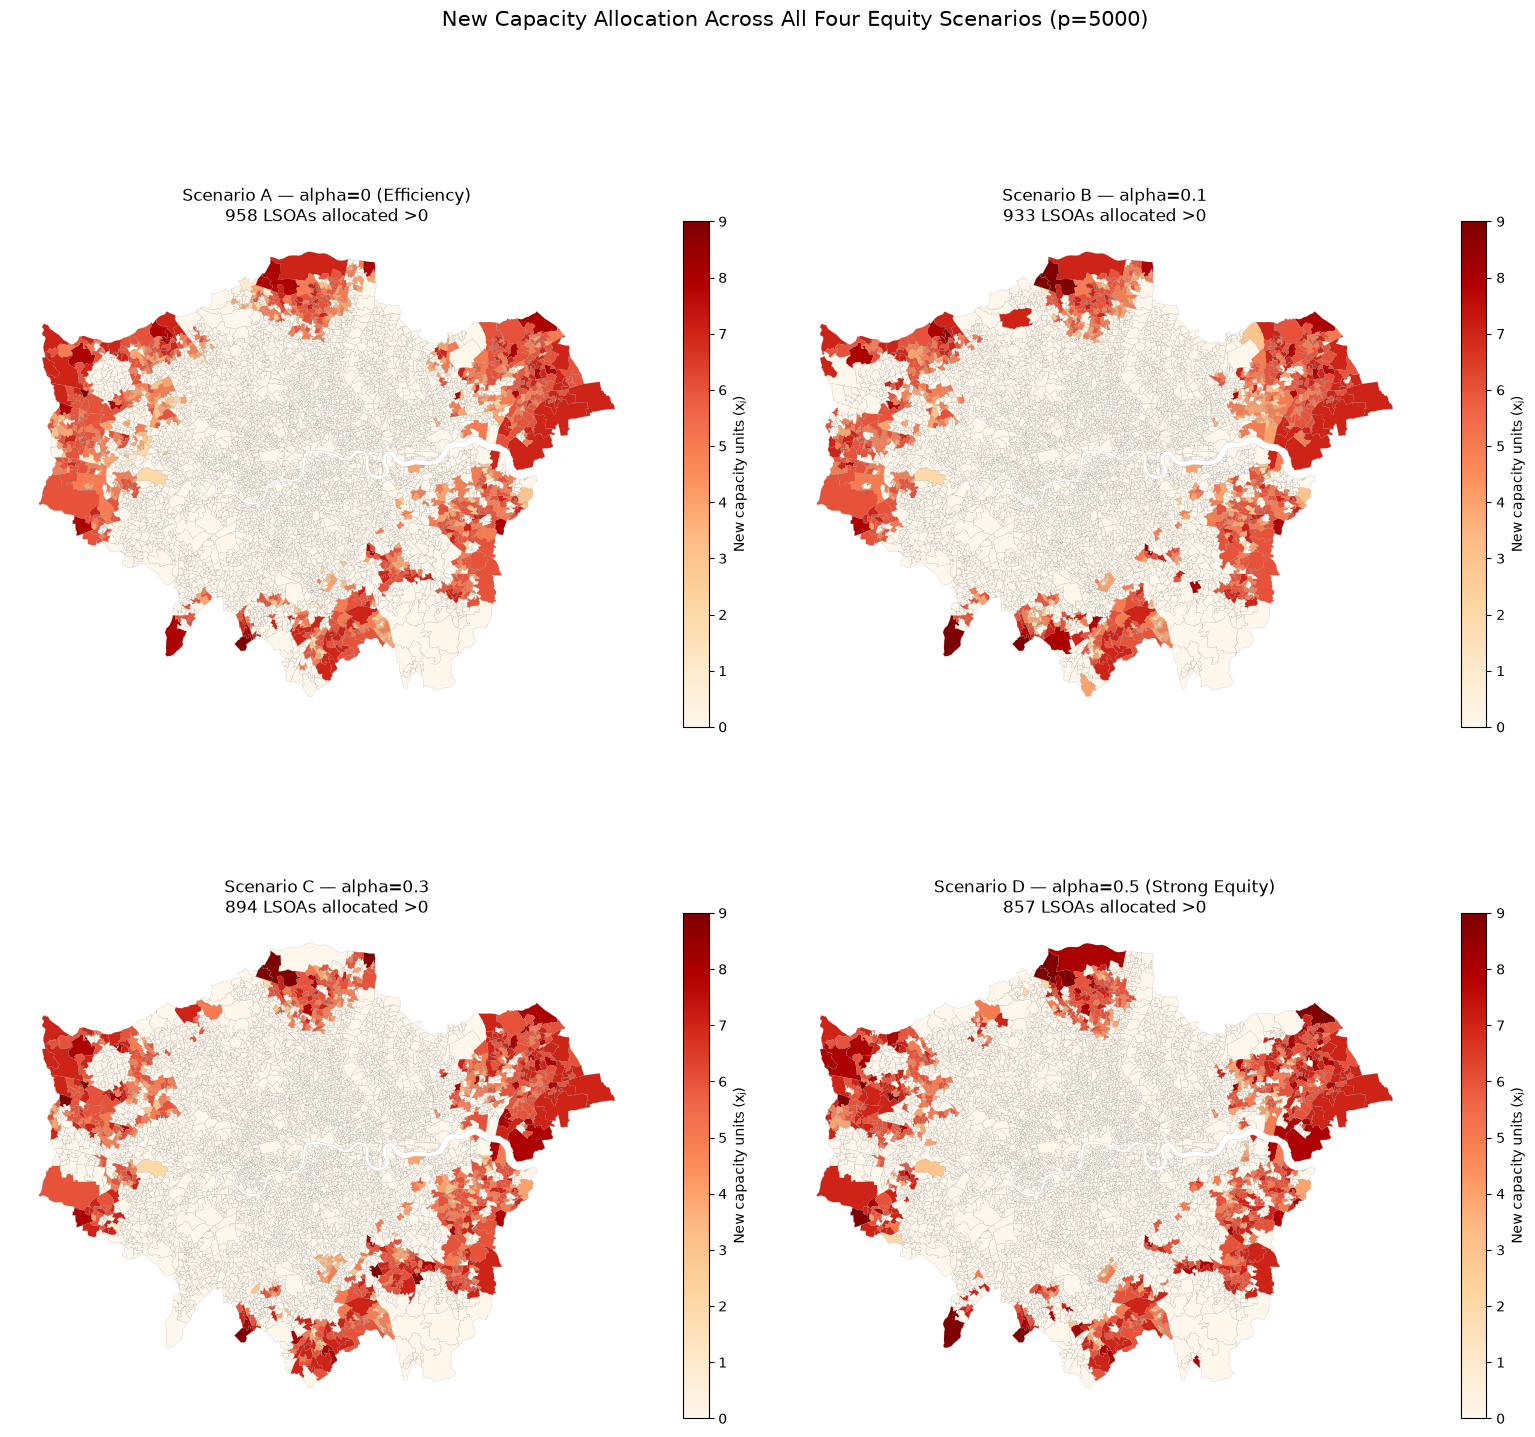

In [9]:
scenario_cols = {s: f"xj_{s}_p{PRIMARY_P}" for s in ["A", "B", "C", "D"]}
shared_vmax = results_wide[list(scenario_cols.values())].max().max()

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
scenario_labels = {"A": "alpha=0 (Efficiency)", "B": "alpha=0.1", "C": "alpha=0.3", "D": "alpha=0.5 (Strong Equity)"}

for ax, s in zip(axes.flat, ["A", "B", "C", "D"]):
    col = scenario_cols[s]
    md_s = lsoa_london.merge(results_wide[["lsoa_code", col]], on="lsoa_code", how="left")
    md_s.plot(column=col, cmap=XJ_CMAP, vmin=0, vmax=shared_vmax, linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": "New capacity units (xⱼ)", "shrink": 0.6})
    n_pos = (results_wide[col] > 0).sum()
    ax.set_title(f"Scenario {s} — {scenario_labels[s]}\n{n_pos:,} LSOAs allocated >0", fontsize=12)
    ax.axis("off")

plt.suptitle(f"New Capacity Allocation Across All Four Equity Scenarios (p={PRIMARY_P})", fontsize=15, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, f"fig_allocation_ABCD_p{PRIMARY_P}.png"), dpi=300, bbox_inches="tight")
plt.show()


## All four scenarios, all three p values (12-panel grid)

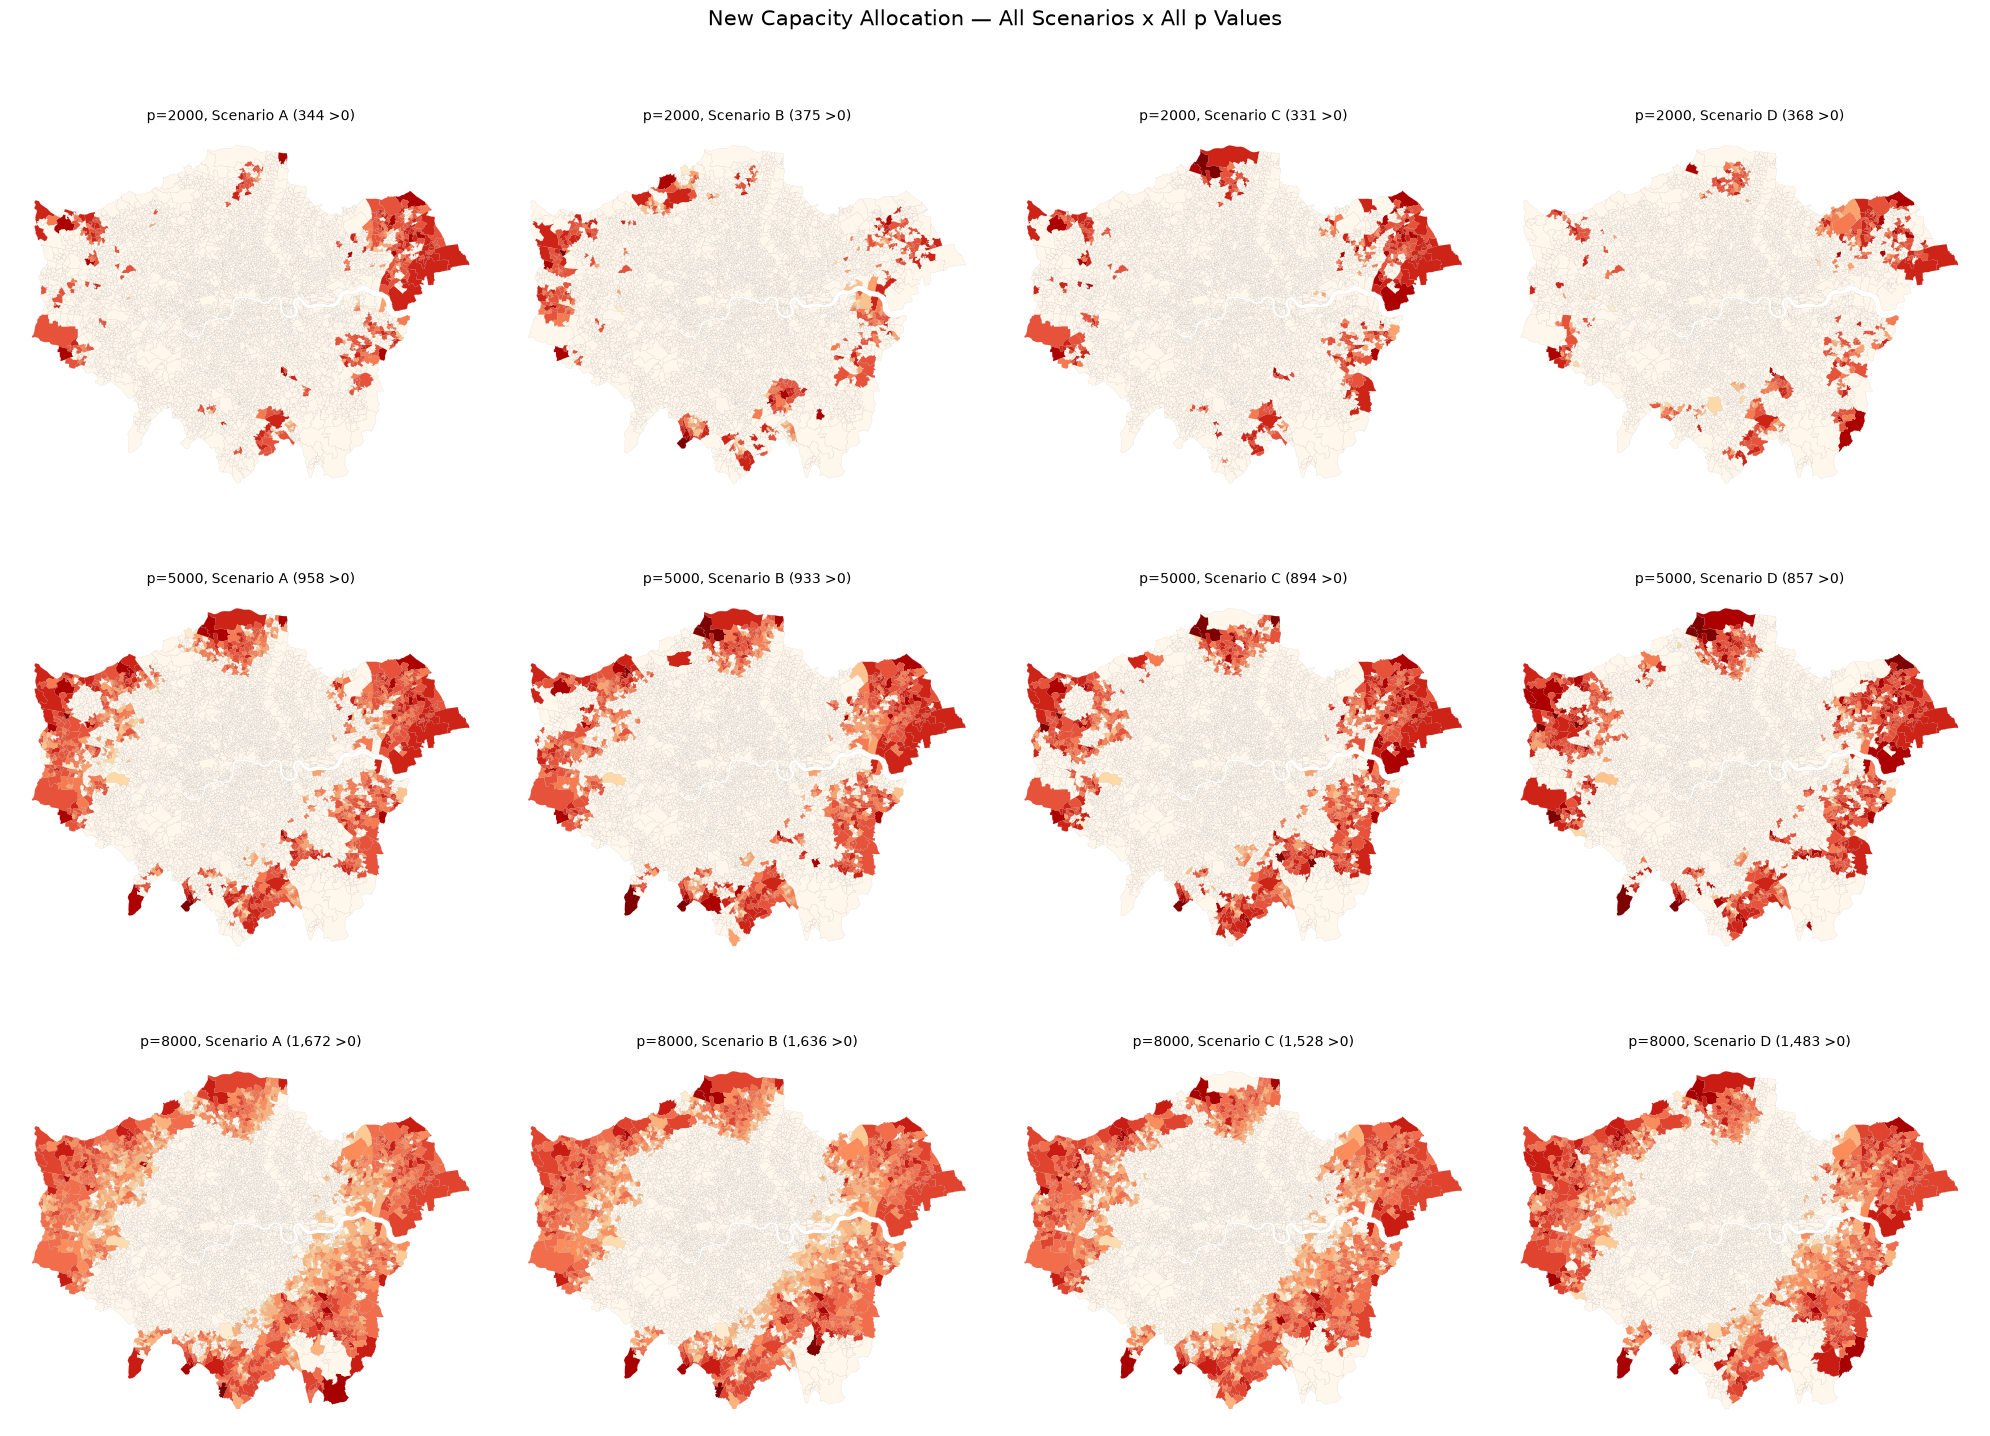

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
p_list = [2000, 5000, 8000]

for row, p in enumerate(p_list):
    cols_this_p = {s: f"xj_{s}_p{p}" for s in ["A", "B", "C", "D"]}
    vmax_this_p = results_wide[list(cols_this_p.values())].max().max()
    for col_i, s in enumerate(["A", "B", "C", "D"]):
        ax = axes[row, col_i]
        col = cols_this_p[s]
        md_s = lsoa_london.merge(results_wide[["lsoa_code", col]], on="lsoa_code", how="left")
        md_s.plot(column=col, cmap=XJ_CMAP, vmin=0, vmax=vmax_this_p, linewidth=0.05,
                  edgecolor="grey", ax=ax, legend=False)
        n_pos = (results_wide[col] > 0).sum()
        ax.set_title(f"p={p}, Scenario {s} ({n_pos:,} >0)", fontsize=10)
        ax.axis("off")

plt.suptitle("New Capacity Allocation — All Scenarios x All p Values", fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_allocation_ABCD_all_p_grid.png"), dpi=300, bbox_inches="tight")
plt.show()
